# Ablation — Axe 4 : DQN vs PPO

**Question :** Le gain du precedence network dépend-il de l'algorithme RL ?

Compare DQN+prec vs PPO+prec (meilleure config WM) sur CartPole et CliffWalking.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
from ablation_utils import *


In [2]:
ENVS = ["CartPole-v1", "CliffWalking-v1"]
results = {}


In [3]:
for env in ENVS:
    results[env] = {}
    for algo in ["dqn", "ppo"]:
        cfg = pick_best_wm_config(algo, env)
        entry = load_precedence_config(algo, env, cfg)
        if entry:
            entry["label"] = f"{algo.upper()}+prec cfg{cfg}"
            results[env][algo] = entry
            print(f"{env} {algo}+prec cfg{cfg}: final={entry['train_final_mean']:.1f} eval={entry.get('eval_mean',0):.1f}")


CartPole-v1 dqn+prec cfg1: final=147.3 eval=462.9
CartPole-v1 ppo+prec cfg2: final=472.1 eval=500.0
CliffWalking-v1 dqn+prec cfg3: final=-14.1 eval=0.0
CliffWalking-v1 ppo+prec cfg2: final=-13.0 eval=0.0


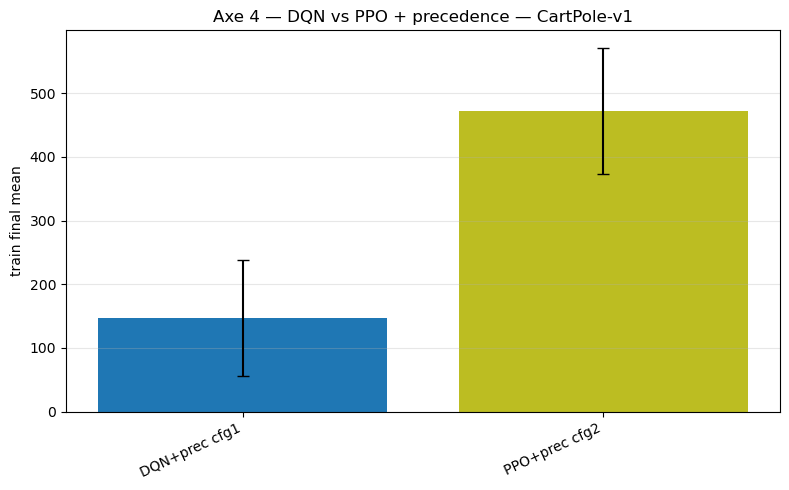

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_algo_CartPole_v1.png


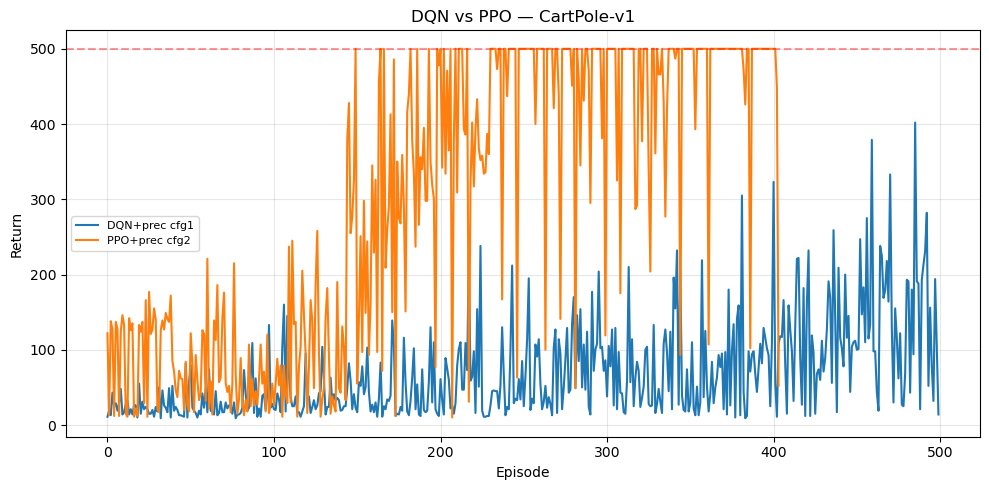

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_algo_curves_CartPole_v1.png


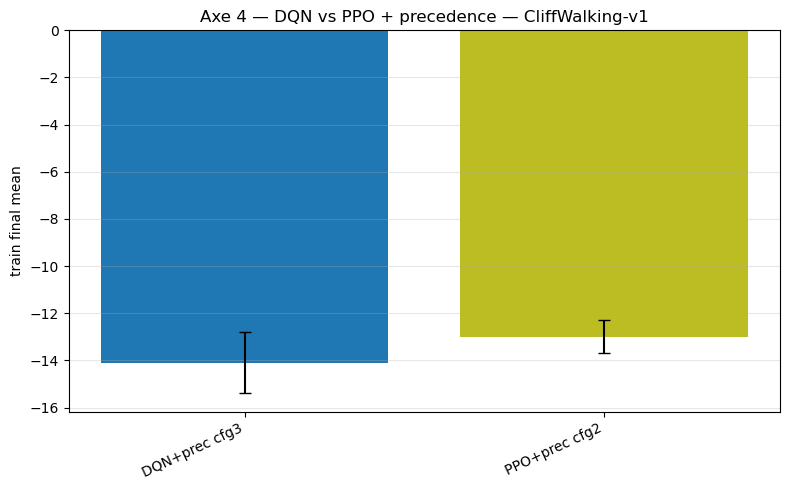

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_algo_CliffWalking_v1.png


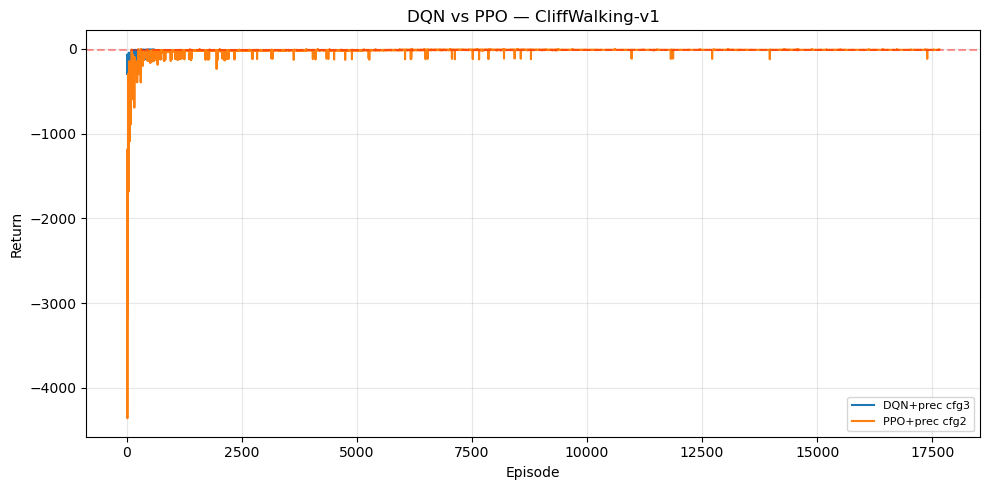

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_algo_curves_CliffWalking_v1.png
✅ Saved → /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_algo.json


PosixPath('/Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_algo.json')

In [4]:
for env in ENVS:
    entries = list(results.get(env, {}).values())
    if len(entries) >= 2:
        plot_bar_comparison(entries, f"Axe 4 — DQN vs PPO + precedence — {env}",
                            f"ablation_algo_{env.replace('-','_')}.png")
        curves = {e["label"]: {"reward_curves": [e.get("rewards", [])]} for e in entries if e.get("rewards")}
        if curves:
            plot_learning_curves(curves, f"DQN vs PPO — {env}", f"ablation_algo_curves_{env.replace('-','_')}.png",
                                 solve_threshold=ENV_SPECS[env]["solve_threshold"])

save_ablation_result("ablation_algo", results)
